# HNSW Project — Week 1: Environment, Dataset, Evaluation Harness & Vanilla Baseline

**CS328 Project | IIT Gandhinagar | 2026**

This notebook covers everything in Week 1 of the project timeline:
1. Install and verify all required libraries
2. Download Fashion-MNIST from ann-benchmarks (includes pre-computed ground truth)
3. Build a reusable evaluation harness (Recall@10 + QPS)
4. Build a vanilla HNSW index with default parameters
5. Plot the Recall@10 vs QPS frontier

---

## Section 1 — Install and Import Libraries

In [21]:
!pip install hnswlib optuna xgboost h5py --quiet

In [22]:
import numpy as np
import time
import h5py
import os
import matplotlib.pyplot as plt
import hnswlib
import optuna
import xgboost
from sklearn.model_selection import train_test_split
from importlib.metadata import version

print(f"numpy      : {np.__version__}")
print(f"hnswlib    : {version('hnswlib')}")
print(f"optuna     : {optuna.__version__}")
print(f"xgboost    : {xgboost.__version__}")
print(f"h5py       : {h5py.__version__}")
print()
print("All libraries imported successfully!")

numpy      : 2.0.2
hnswlib    : 0.8.0
optuna     : 4.8.0
xgboost    : 3.2.0
h5py       : 3.16.0

All libraries imported successfully!


## Section 2 — Download Fashion-MNIST from ann-benchmarks

The [ann-benchmarks](https://github.com/erikbern/ann-benchmarks) suite provides standardised ANN datasets as HDF5 files. Each file contains:
- `train` — base vectors that go into the index
- `test` — query vectors
- `neighbors` — pre-computed **exact** ground truth nearest neighbors for each query
- `distances` — the corresponding exact distances

This is the same ground truth used in every ANN paper, making our results directly comparable to published work.

> **File size:** ~200 MB. Download takes about 2-4 minutes on Colab.

In [23]:
DATASET_URL  = "http://ann-benchmarks.com/fashion-mnist-784-euclidean.hdf5"
DATASET_FILE = "fashion-mnist-784-euclidean.hdf5"

if os.path.exists(DATASET_FILE):
    print(f"Dataset already present: {DATASET_FILE}")
else:
    print("Downloading Fashion-MNIST from ann-benchmarks (~200 MB)...")
    t0 = time.time()
    !wget -q --show-progress -O {DATASET_FILE} {DATASET_URL}
    print(f"Done in {time.time() - t0:.1f}s")

print(f"File size: {os.path.getsize(DATASET_FILE) / 1e6:.1f} MB")

Dataset already present: fashion-mnist-784-euclidean.hdf5
File size: 227.5 MB


In [24]:
with h5py.File(DATASET_FILE, 'r') as f:
    print("Keys in HDF5 file:", list(f.keys()))
    print()

    base_vectors  = f['train'][:].astype(np.float32)      # shape: (60000, 784)
    query_vectors = f['test'][:].astype(np.float32)       # shape: (10000, 784)
    ground_truth  = f['neighbors'][:].astype(np.int32)    # shape: (10000, 100)

# ann-benchmarks stores 100 neighbors — we only need top-10
ground_truth = ground_truth[:, :10]

print(f"Base vectors  (to index) : {base_vectors.shape}")
print(f"Query vectors (to search): {query_vectors.shape}")
print(f"Ground truth (10-NNs)    : {ground_truth.shape}")
print()
print(f"Example — query 0 true neighbor indices : {ground_truth[0]}")

Keys in HDF5 file: ['distances', 'neighbors', 'test', 'train']

Base vectors  (to index) : (60000, 784)
Query vectors (to search): (10000, 784)
Ground truth (10-NNs)    : (10000, 10)

Example — query 0 true neighbor indices : [18094 53939 18352 52468 15081 29768 21342 17346 45266 18339]


## Section 3 — Train / Test Split

The proposal specifies **80% train / 20% test** on the query set.
- **Training queries** are used in Week 2+ to supervise parameter learning
- **Test queries** are the held-out set for unbiased final evaluation

We define this split once and reuse it consistently every week.

In [25]:
Q = query_vectors.shape[0]  # 10,000
all_indices = np.arange(Q)

train_idx, test_idx = train_test_split(all_indices, test_size=0.2, random_state=42)

train_queries = query_vectors[train_idx]   # 8,000 queries
test_queries  = query_vectors[test_idx]    # 2,000 queries

train_gt = ground_truth[train_idx]
test_gt  = ground_truth[test_idx]

print(f"Training query set : {train_queries.shape}")
print(f"Test query set     : {test_queries.shape}")
print()

# Save for reuse across weeks
np.save('train_queries.npy', train_queries)
np.save('test_queries.npy',  test_queries)
np.save('train_gt.npy',      train_gt)
np.save('test_gt.npy',       test_gt)

print("Splits saved to be downloaded for future use.")

Training query set : (8000, 784)
Test query set     : (2000, 784)

Splits saved to be downloaded for future use.


## Section 4 — Evaluation Harness

This is the core measurement function we will reuse throughout the entire project.

**Recall@10:** For each query, what fraction of its true 10 nearest neighbors did HNSW return? Averaged across all queries. A score of 1.0 means perfect — HNSW found all 10 true neighbors for every query.

**QPS (Queries Per Second):** How many queries the index can answer per second at a given `ef_search` setting.

Sweeping `ef_search` traces out the full **Recall vs QPS frontier**. This is the standard evaluation method in ANN research.

In [26]:
def evaluate_index(index, query_vectors, ground_truth, ef_search_values, k=10):
    """
    Evaluate an HNSW index across a range of ef_search values.

    Parameters
    ----------
    index            : hnswlib.Index
    query_vectors    : np.ndarray, shape (Q, dim)
    ground_truth     : np.ndarray, shape (Q, k) — true nearest neighbor indices
    ef_search_values : list[int]
    k                : int — number of neighbors to retrieve

    Returns
    -------
    results : list of dicts with keys: 'ef_search', 'recall', 'qps'
    """
    results = []
    Q = query_vectors.shape[0]

    for ef in ef_search_values:
        index.set_ef(ef)

        t0 = time.time()
        labels, distances = index.knn_query(query_vectors, k=k)
        elapsed = time.time() - t0

        qps = Q / elapsed

        # Recall@k: for each query, fraction of true neighbors found
        recall = np.mean([
            len(set(labels[i]) & set(ground_truth[i])) / k
            for i in range(Q)
        ])

        results.append({'ef_search': ef, 'recall': recall, 'qps': qps})
        print(f"  ef_search={ef:4d} | Recall@10={recall:.4f} | QPS={qps:8.1f}")

    return results


print("Evaluation harness defined.")

Evaluation harness defined.


## Section 5 — Build Vanilla HNSW Baseline

We build an HNSW index with **default parameters** as documented in hnswlib:
- `M = 16` — max edges per node
- `ef_construction = 200` — beam width during construction

These are the fixed hand-tuned values our project will learn to improve upon.

In [27]:
def build_hnsw_index(base_vectors, M, ef_construction, space='l2', seed=42):
    """
    Build and return an HNSW index.

    Parameters
    ----------
    base_vectors    : np.ndarray, shape (N, dim)
    M               : int — max edges per node
    ef_construction : int — beam width during construction
    space           : str — 'l2' or 'cosine'
    seed            : int — random seed for reproducibility

    Returns
    -------
    index        : hnswlib.Index
    build_time_s : float
    """
    dim = base_vectors.shape[1]
    N   = base_vectors.shape[0]

    index = hnswlib.Index(space=space, dim=dim)
    index.init_index(max_elements=N, ef_construction=ef_construction, M=M, random_seed=seed)

    t0 = time.time()
    index.add_items(base_vectors, np.arange(N))
    build_time = time.time() - t0

    return index, build_time


M_default               = 16
ef_construction_default = 200

print("Building vanilla HNSW index...")
print(f"  M={M_default}, ef_construction={ef_construction_default}")
print(f"  {base_vectors.shape[0]:,} vectors | dim={base_vectors.shape[1]}")

vanilla_index, build_time = build_hnsw_index(
    base_vectors,
    M=M_default,
    ef_construction=ef_construction_default
)

print(f"\nIndex built in {build_time:.2f}s")
print(f"Elements indexed: {vanilla_index.get_current_count():,}")

Building vanilla HNSW index...
  M=16, ef_construction=200
  60,000 vectors | dim=784

Index built in 42.77s
Elements indexed: 60,000


## Section 6 — Run Evaluation on Test Split

In [28]:
ef_search_values = [10, 20, 30, 50, 80, 100, 150, 200, 300, 500]

print("Sweeping ef_search on held-out test queries (2,000 queries)...")
print(f"{'ef_search':>10} | {'Recall@10':>10} | {'QPS':>10}")
print("-" * 38)

vanilla_results = evaluate_index(
    vanilla_index,
    test_queries,
    test_gt,
    ef_search_values,
    k=10
)

Sweeping ef_search on held-out test queries (2,000 queries)...
 ef_search |  Recall@10 |        QPS
--------------------------------------
  ef_search=  10 | Recall@10=0.9315 | QPS= 13245.8
  ef_search=  20 | Recall@10=0.9786 | QPS=  9050.9
  ef_search=  30 | Recall@10=0.9898 | QPS=  6475.7
  ef_search=  50 | Recall@10=0.9958 | QPS=  4665.5
  ef_search=  80 | Recall@10=0.9980 | QPS=  3425.3
  ef_search= 100 | Recall@10=0.9983 | QPS=  3008.4
  ef_search= 150 | Recall@10=0.9990 | QPS=  1975.4
  ef_search= 200 | Recall@10=0.9990 | QPS=  1158.0
  ef_search= 300 | Recall@10=0.9992 | QPS=  1103.8
  ef_search= 500 | Recall@10=0.9998 | QPS=   931.7


## Section 7 — Plot the Recall@10 vs QPS Frontier

Standard ANN evaluation plot. Each point = one `ef_search` value.
- **Upper-right is better** — higher recall at the same speed, or same recall but faster
- We define this as a reusable function where we will overlay new curves on this same baseline for comparison.

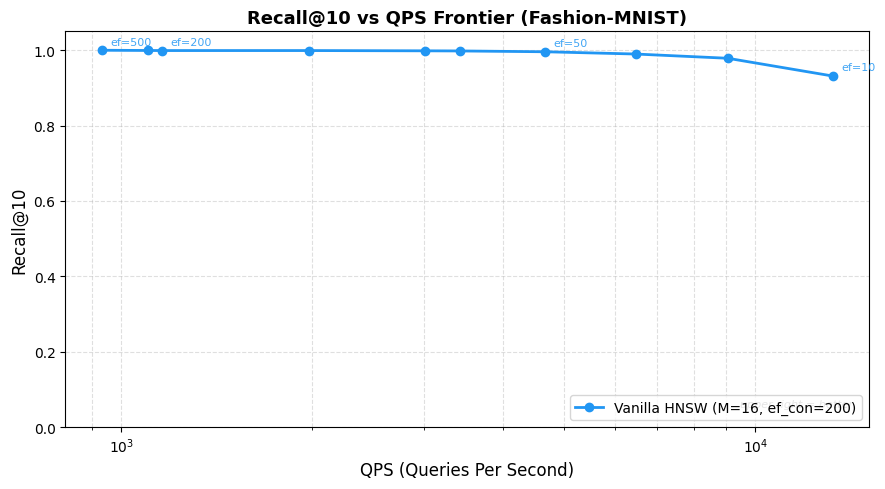

Plot saved to recall_qps.png


In [29]:
def plot_recall_qps(results_list, labels, title='Recall@10 vs QPS Frontier', filename='recall_qps.png'):
    """
    Plot one or more Recall@10 vs QPS curves on the same axes.

    Parameters
    ----------
    results_list : list of lists of dicts — one list per method
    labels       : list of str — one label per method
    title        : str
    filename     : str — output filename for saved plot
    """
    colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    markers = ['o', 's', '^', 'D']

    fig, ax = plt.subplots(figsize=(9, 5))

    for i, (results, label) in enumerate(zip(results_list, labels)):
        recalls = [r['recall']    for r in results]
        qps     = [r['qps']       for r in results]
        efs     = [r['ef_search'] for r in results]
        color   = colors[i % len(colors)]
        marker  = markers[i % len(markers)]

        ax.plot(qps, recalls, marker=marker, color=color, label=label,
                linewidth=2, markersize=6, zorder=3)

        # Annotate a few key ef_search values for readability
        for qp, rc, ef in zip(qps, recalls, efs):
            if ef in [10, 50, 200, 500]:
                ax.annotate(f'ef={ef}', (qp, rc),
                            textcoords='offset points', xytext=(6, 4),
                            fontsize=8, color=color, alpha=0.85)

    ax.set_xlabel('QPS (Queries Per Second)', fontsize=12)
    ax.set_ylabel('Recall@10', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_xscale('log')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.legend(fontsize=10, loc='lower right')
    ax.text(0.98, 0.05, 'upper-right = better',
            transform=ax.transAxes, fontsize=8, color='gray',
            ha='right', style='italic')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to {filename}")


plot_recall_qps(
    [vanilla_results],
    [f'Vanilla HNSW (M={M_default}, ef_con={ef_construction_default})'],
    title='Recall@10 vs QPS Frontier (Fashion-MNIST)'
)

## Section 8 — Summary

In [30]:
print("=" * 57)
print("RESULTS — Vanilla HNSW Baseline")
print("=" * 57)
print(f"  Dataset      : Fashion-MNIST (ann-benchmarks HDF5)")
print(f"  Base vectors : {base_vectors.shape[0]:,} x {base_vectors.shape[1]}")
print(f"  Test queries : {test_queries.shape[0]:,} (held-out 20% split)")
print(f"  Ground truth : pre-computed exact 10-NNs from ann-benchmarks")
print(f"  M            : {M_default}")
print(f"  ef_con       : {ef_construction_default}")
print(f"  Build time   : {build_time:.2f}s")
print()
print(f"  {'ef_search':>10} | {'Recall@10':>10} | {'QPS':>12}")
print(f"  " + "-" * 42)
for r in vanilla_results:
    print(f"  {r['ef_search']:>10} | {r['recall']:>10.4f} | {r['qps']:>12.1f}")
print("=" * 57)

best = max(vanilla_results, key=lambda x: x['recall'])
print(f"\n  Best Recall@10 = {best['recall']:.4f} at ef_search={best['ef_search']} (QPS={best['qps']:.1f})")
print()
print("  This curve is the reference. All other comparison curves will be plotted against it.")

RESULTS — Vanilla HNSW Baseline
  Dataset      : Fashion-MNIST (ann-benchmarks HDF5)
  Base vectors : 60,000 x 784
  Test queries : 2,000 (held-out 20% split)
  Ground truth : pre-computed exact 10-NNs from ann-benchmarks
  M            : 16
  ef_con       : 200
  Build time   : 42.77s

   ef_search |  Recall@10 |          QPS
  ------------------------------------------
          10 |     0.9315 |      13245.8
          20 |     0.9786 |       9050.9
          30 |     0.9898 |       6475.7
          50 |     0.9958 |       4665.5
          80 |     0.9980 |       3425.3
         100 |     0.9983 |       3008.4
         150 |     0.9990 |       1975.4
         200 |     0.9990 |       1158.0
         300 |     0.9992 |       1103.8
         500 |     0.9998 |        931.7

  Best Recall@10 = 0.9998 at ef_search=500 (QPS=931.7)

  This curve is the reference. All other comparison curves will be plotted against it.
